# O básico de CNN

Convolução, em termos simples, é uma forma de misturar duas informações. Imagine que você tem uma receita de bolo que dá o sabor e uma forma que dá o formato do bolo. A convolução entre a receita e a forma produz o bolo final com um certo sabor e formato.

No contexto das redes neurais convolucionais (CNNs) e processamento de imagens, a convolução é uma operação matemática que faz a "mistura" entre a imagem de entrada e um filtro (ou kernel) para extrair características da imagem.

Imagine que você tem uma foto e um pequeno quadrado transparente com um padrão específico nele, que é o seu filtro. Quando você coloca o quadrado sobre a foto, você consegue ver apenas a parte da foto através do padrão. Ao mover esse quadrado por toda a extensão da foto, o padrão "captura" ou "destaca" diferentes características dependendo de onde está. Por exemplo, se o padrão é feito para reconhecer bordas verticais, ele vai "iluminar" as partes da foto onde encontra bordas verticaicação é feita.

Existem alguns termos importantes neste contexto. Abaixo, uma versão simplificada destes termos, que iremos aprimorar à medida que avançamos:

- **Filtro**: É o padrão que você está procurando na imagem. No exemplo acima, é o quadrado transparente com um padrão específico.
  
- **Stride (Passo)**: É o número de passos que você dá ao mover o quadrado (filtro) pela foto. Um passo maior pula mais partes da foto, enquanto um passo menor move o quadrado mais lentamente, capturando mais detalhes.
  
- **Padding (Preenchimento)**: Se você quer usar o padrão (filtro) nas bordas da foto também, você pode adicionar uma margem extra ao redor da foto. Isso garante que cada parte da foto, incluindo as bordas, seja analisada pelo padrão (filtro).

Portanto, a convolução nos permite aplicar filtros para detectar padrões específicos em imagens, e os parâmetros como stride e padding nos ajudam a controlar como essa aplicação é feita.

https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D

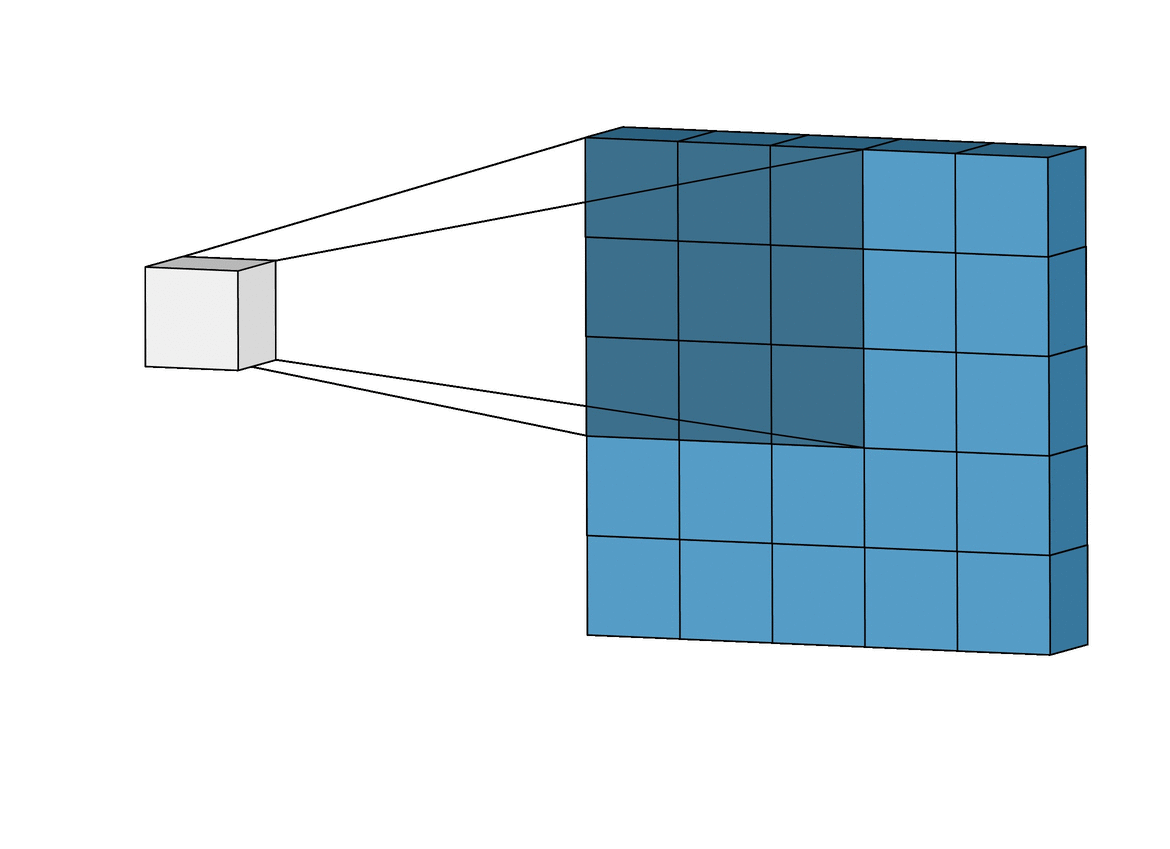

Vamos detalhar cada um dos termos associados a uma operação de convolução em uma rede neural convolucional (CNN) usando `Conv2D`:

1. **Filtro (Filter)**: Um filtro é um conjunto de aprendizado de pesos que a rede vai ajustar durante o treinamento. Cada filtro é responsável por capturar uma característica específica na imagem, como bordas, cores ou outras texturas. Em uma camada `Conv2D`, você pode ter vários filtros, cada um gerando um mapa de características diferente a partir da mesma entrada.

2. **Kernel**: O kernel é o nome dado ao conjunto de pesos que compõem um único filtro. É uma pequena matriz que desliza sobre a imagem de entrada para realizar a operação de convolução. Por exemplo, um kernel de tamanho $3 \times 3$ tem 9 pesos que são aprendidos durante o treinamento da rede. O kernel é aplicado repetidamente a todas as áreas da imagem para produzir um mapa de características.

3. **Stride (Passo)**: O stride define quantos pixels o kernel se move a cada passo da operação de convolução. Um stride de 1 significa que o kernel se move um pixel por vez. Um stride maior pode fazer o kernel pular pixels da entrada e resultará em um mapa de características menor. O stride ajuda a controlar o tamanho do mapa de características de saída e também pode ajudar a rede a ser mais resistente a pequenas variações na entrada.

4. **Padding (Preenchimento)**: Padding é a prática de adicionar pixels artificiais ao redor da imagem de entrada. Isso é feito para que o kernel possa ser aplicado às bordas da imagem. Sem padding, a convolução reduziria o tamanho da saída porque os kernels não caberiam nas bordas. O padding "valid" significa que nenhum padding é aplicado, e o padding "same" significa que é aplicado o suficiente para que o tamanho de saída seja o mesmo que o tamanho de entrada quando o stride é 1.

Esses componentes são são ajustados durante o processo de definição da arquitetura da rede e durante o treinamento para capturar as características mais importantes para a tarefa que a rede está tentando realizar.

Exemplo com padding:

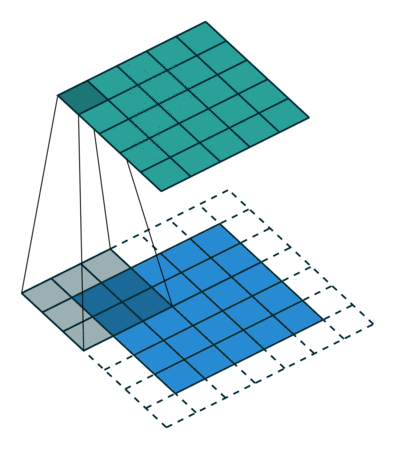

## Max pooling e average pooling

O termo "pooling" refere-se à ideia de agrupar um conjunto de valores e, em seguida, resumir esse conjunto com uma única medida estatística. Em inglês, a palavra "pool" pode se referir a uma coleção ou agregação de recursos, como um "pool de recursos" ou um "pool de talentos". No contexto de redes neurais convolucionais (CNNs), o termo "pooling" está associado à operação que agrega informações espaciais.
.

Portanto, o "pooling" serve para criar uma representação compacta do que foi aprendido pelas camadas convolucionais, agrupando os dados espaciais em medidas resumidas, e isso ajuda a tornar a rede mais eficiente e robusta a variações menores nas imagens de entrada.

Camadas de pooling são usadas em redes neurais convolucionais (CNNs) principalmente por três razões:

1. **Redução de Dimensionalidade**: O pooling ajuda a reduzir as dimensões do mapa de características (também conhecido como feature map). Ao fazer isso, diminui-se a quantidade de parâmetros e cálculos subsequentes na rede, o que pode levar a um aumento na eficiência computacional durante o treinamento e a inferência do modelo.

2. **Controle de Overfitting**: Reduzindo o número de parâmetros, o pooling também pode ajudar a prevenir o overfitting. Com menos detalhes para aprender, o modelo é incentivado a capturar as características mais essenciais das imagens, em vez de memorizar detalhes específicos do conjunto de treinamento que podem não generalizar bem para novos dados.

3. **Invariância a Translações Menores**: As camadas de pooling tornam a representação obtida pela rede ligeiramente invariante a pequenas translações, rotações e outras formas de deformação. Por exemplo, após uma camada de pooling, se a imagem de entrada for ligeiramente deslocada ou girada, o mapa de características resultante pode não mudar muito. Isso é útil porque queremos que a rede reconheça objetos e características independentemente de sua posição exata na imagem.

Existem diferentes tipos de operações de pooling, sendo o max pooling e o average pooling os mais comuns. No max pooling, o valor máximo dentro de uma janela (por exemplo, 2x2 pixels) é mantido, enquanto todos os outros valores são descartados. No average pooling, a média dos valores dentro da janela é calculada e usada. O max pooling é particularmente bom para capturar a presença de características enquanto ignora variações menores e ruídos.

O uso de max pooling ou average pooling em uma rede neural convolucional depende das características que você deseja capturar do seu mapa de características (feature map):

Max Pooling:

- **Capturar a presença de características**: O max pooling é usado quando o mais importante é a presença ou não de uma característica específica numa região da imagem. Ele pega o valor máximo de uma janela de valores, o que significa que se a característica está presente em pelo menos um pixel da janela, ela será capturada.

- **Invariância a pequenas variações**: Max pooling é bom para quando queremos que nossa rede seja robusta a pequenas variações e distorções na imagem, já que ele mantém apenas o valor mais forte (mais alto) dentro de uma região.

- **Detectar texturas e padrões**: É comum usar max pooling em tarefas onde a textura ou padrões específicos são importantes, como em reconhecimento de imagens onde queremos detectar objetos, independentemente de sua posição exata na imagem.

Average Pooling:

- **Suavizar as características**: O average pooling calcula a média dos valores dentro da janela de pooling. Ele é útil para suavizar as características do mapa de ativação.

- **Manter informações de fundo**: Se a informação de fundo ou o contexto geral da imagem é importante, o average pooling pode ser preferível, pois ele não descarta os pixels com valores menores, diferentemente do max pooling.
- **Prevenir características muito dominantes**: Em algumas situações, você pode não querer que características muito fortes dominem a representação aprendida. O average pooling garante que todas as entradas da janela de pooling contribuam para a saída.
 
Em resumo, max pooling é geralmente preferido quando a localização exata das características não é essencial, mas sim a sua presença mais forte. Por outro lado, average pooling pode ser mais adequado para quando você deseja preservar mais a informação geral ou contexto da região da imagem.

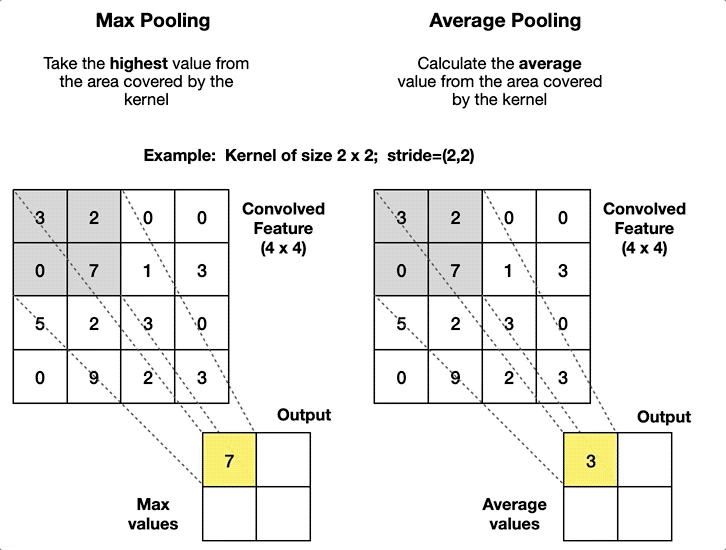

https://www.tensorflow.org/api_docs/python/tf/keras/layers/AveragePooling2D

In [1]:
import os

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [2]:
import tensorflow as tf

data = tf.constant(
    [
        [0, 0, 0, 1, 1, 0, 0, 0],
        [0, 0, 0, 1, 1, 0, 0, 0],
        [0, 0, 0, 1, 1, 0, 0, 0],
        [0, 0, 0, 1, 1, 0, 0, 0],
        [0, 0, 0, 1, 1, 0, 0, 0],
        [0, 0, 0, 1, 1, 0, 0, 0],
        [0, 0, 0, 1, 1, 0, 0, 0],
        [0, 0, 0, 1, 1, 0, 0, 0],
    ]
)

data = tf.reshape(data, [1, 8, 8, 1])
data

<tf.Tensor: shape=(1, 8, 8, 1), dtype=int32, numpy=
array([[[[0],
         [0],
         [0],
         [1],
         [1],
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         [1],
         [1],
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         [1],
         [1],
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         [1],
         [1],
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         [1],
         [1],
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         [1],
         [1],
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         [1],
         [1],
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         [1],
         [1],
         [0],
         [0],
         [0]]]], dtype=int32)>

In [ ]:
from tensorflow import keras

model_with_avg_pool = keras.Sequential()

model_with_avg_pool.add(keras.layers.InputLayer([8, 8, 1]))
model_with_avg_pool.add(keras.layers.Conv2D(1, (3, 3), activation="linear"))
model_with_avg_pool.add(keras.layers.AveragePooling2D())

model_with_avg_pool.summary()

In [4]:
kernel = tf.constant(
    [
        [0, 1, 0],
        [0, 1, 0],
        [0, 1, 0],
    ]
)

kernel = tf.reshape(kernel, [3, 3, 1, 1])

weights = [kernel, tf.constant([0.0])]

model_with_avg_pool.set_weights(weights)

In [5]:
model_with_avg_pool.weights

[<Variable path=sequential/conv2d/kernel, shape=(3, 3, 1, 1), dtype=float32, value=[[[[0.]]
 
   [[1.]]
 
   [[0.]]]
 
 
  [[[0.]]
 
   [[1.]]
 
   [[0.]]]
 
 
  [[[0.]]
 
   [[1.]]
 
   [[0.]]]]>,
 <Variable path=sequential/conv2d/bias, shape=(1,), dtype=float32, value=[0.]>]

In [ ]:
y_pred = model_with_avg_pool.predict(data)

In [ ]:
y_pred

In [ ]:
tf.reshape(y_pred, [3, 3])